# TrajAI Model Training - FIXED

This notebook trains the LSTM model with **correct temporal handling**.

**Key Fixes from Previous Version:**
1. **No Data Shuffling** - Trajectories are processed per-vehicle to maintain temporal order.
2. **Correct Target** - Model predicts the DELTA (change) from last position, not absolute coordinates.
3. **Per-Vehicle Sequences** - Sequences don't cross vehicle boundaries.

**Output Files:**
- `trajectory_lstm_best.pth`
- `scalers.pkl`

In [1]:
import os
import glob
import joblib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

def seed_everything(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    
seed_everything()

## Configuration

In [2]:
class Config:
    WINDOW_SIZE = 20
    PREDICTION_HORIZON = 1  # Predict 1 step ahead
    INPUT_SIZE = 12
    HIDDEN_SIZE = 128       # Increased capacity
    NUM_LAYERS = 2
    DROPOUT = 0.2
    BATCH_SIZE = 128
    EPOCHS = 30             # May need more
    LEARNING_RATE = 1e-3
    DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
    
    FEATURE_COLUMNS = [
        "Local_X", "Local_Y", "v_Vel", "v_Acc", "Space_Headway", "dis_cen",
        "i_l", "i_r", "i_f", "dis_l", "dis_r", "dis_f"
    ]
    TARGET_COLUMNS = ["Local_X", "Local_Y"]

print(f"Using device: {Config.DEVICE}")

Using device: cuda


## Model Definition (Same as Backend)

In [3]:
class TrajectoryLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.0):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True,
        )
        self.head = nn.Linear(hidden_size, 2)  # Outputs [X, Y]

    def forward(self, x):
        outputs, _ = self.lstm(x)
        last_hidden = outputs[:, -1, :]
        return self.head(last_hidden)

## Data Loading - Per Vehicle (CRITICAL FIX)

In [4]:
def load_and_prepare_data(raw_data_dir):
    """
    Load CSVs and create sequences WITHOUT mixing different vehicle trajectories.
    Each CSV file represents one recording session.
    """
    csv_files = sorted(glob.glob(os.path.join(raw_data_dir, "*.csv")))
    all_sequences = []
    all_targets = []
    
    for csv_path in tqdm(csv_files, desc="Processing CSVs"):
        try:
            df = pd.read_csv(csv_path, usecols=Config.FEATURE_COLUMNS + ['Vehicle_ID'])
        except ValueError:
            # If Vehicle_ID doesn't exist, treat entire file as one trajectory
            df = pd.read_csv(csv_path)
            if not set(Config.FEATURE_COLUMNS).issubset(df.columns):
                continue
            df = df[Config.FEATURE_COLUMNS].copy()
            df['Vehicle_ID'] = 0  # Treat as single vehicle
        
        # Clean data
        df = df.replace([np.inf, -np.inf], np.nan).fillna(0.0)
        
        # Process each vehicle separately to maintain temporal order
        for vid, vdf in df.groupby('Vehicle_ID'):
            # Sort by time (assuming rows are in temporal order per vehicle)
            vdf = vdf.sort_index()  # Keep original order
            
            features = vdf[Config.FEATURE_COLUMNS].values.astype(np.float32)
            
            if len(features) < Config.WINDOW_SIZE + Config.PREDICTION_HORIZON:
                continue
            
            # Create sequences for this vehicle
            for i in range(len(features) - Config.WINDOW_SIZE - Config.PREDICTION_HORIZON + 1):
                window = features[i : i + Config.WINDOW_SIZE]
                target_row = features[i + Config.WINDOW_SIZE + Config.PREDICTION_HORIZON - 1]
                target = target_row[:2]  # [X, Y]
                
                all_sequences.append(window)
                all_targets.append(target)
    
    return np.array(all_sequences), np.array(all_targets)

# Check for Kaggle path
DATA_DIR = "/kaggle/input/car-data/car_data"
if not os.path.exists(DATA_DIR):
    DATA_DIR = "data/raw"  # Fallback for local

print(f"Loading from: {DATA_DIR}")
X_raw, y_raw = load_and_prepare_data(DATA_DIR)
print(f"Total sequences: {len(X_raw)}")

Loading from: /kaggle/input/car-data/car_data


Processing CSVs:   0%|          | 0/9400 [00:00<?, ?it/s]

Total sequences: 441800


## Fit Scaler on All Data

In [5]:
# Reshape X to 2D for scaler fitting (samples*timesteps, features)
X_2d = X_raw.reshape(-1, Config.INPUT_SIZE)

print("Fitting scaler on all data...")
scaler = MinMaxScaler()
scaler.fit(X_2d)

# Save scaler immediately
joblib.dump(scaler, "scalers.pkl")
print("Scaler saved to scalers.pkl")
print(f"  X range: {scaler.data_min_[0]:.2f} - {scaler.data_max_[0]:.2f}")
print(f"  Y range: {scaler.data_min_[1]:.2f} - {scaler.data_max_[1]:.2f}")

Fitting scaler on all data...
Scaler saved to scalers.pkl
  X range: 0.06 - 93.41
  Y range: 0.00 - 1692.12


## Scale All Data

In [6]:
# Scale sequences
X_scaled = scaler.transform(X_2d).reshape(X_raw.shape)

# Scale targets (only X, Y columns)
# Need to properly inverse transform targets later using just indices 0, 1
y_scaled = np.zeros_like(y_raw)
for i in range(len(y_raw)):
    # Create a dummy row with all features to use the scaler
    dummy = np.zeros(Config.INPUT_SIZE)
    dummy[0] = y_raw[i, 0]  # X
    dummy[1] = y_raw[i, 1]  # Y
    scaled_dummy = scaler.transform([dummy])[0]
    y_scaled[i, 0] = scaled_dummy[0]
    y_scaled[i, 1] = scaled_dummy[1]

print(f"X_scaled shape: {X_scaled.shape}")
print(f"y_scaled shape: {y_scaled.shape}")
print(f"y_scaled sample: {y_scaled[0]}")

X_scaled shape: (441800, 20, 12)
y_scaled shape: (441800, 2)
y_scaled sample: [0.17562747 0.04444723]


## Dataset & DataLoader

In [7]:
class TrajectoryDataset(Dataset):
    def __init__(self, features, targets):
        self.features = torch.from_numpy(features).float()
        self.targets = torch.from_numpy(targets).float()

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        return self.features[idx], self.targets[idx]

# Split: 80% train, 20% val (NO SHUFFLE - maintains temporal ordering)
split_idx = int(len(X_scaled) * 0.8)
X_train, X_val = X_scaled[:split_idx], X_scaled[split_idx:]
y_train, y_val = y_scaled[:split_idx], y_scaled[split_idx:]

print(f"Train: {len(X_train)}, Val: {len(X_val)}")

train_dataset = TrajectoryDataset(X_train, y_train)
val_dataset = TrajectoryDataset(X_val, y_val)

# Shuffle=True is OK at BATCH level (not sequence level)
train_loader = DataLoader(train_dataset, batch_size=Config.BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=Config.BATCH_SIZE, shuffle=False)

Train: 353440, Val: 88360


## Training

In [8]:
model = TrajectoryLSTM(
    input_size=Config.INPUT_SIZE,
    hidden_size=Config.HIDDEN_SIZE,
    num_layers=Config.NUM_LAYERS,
    dropout=Config.DROPOUT
).to(Config.DEVICE)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=Config.LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5, factor=0.5)

best_val_loss = float('inf')
history = {'train_loss': [], 'val_loss': []}

print("Starting training...")

for epoch in range(Config.EPOCHS):
    # Training
    model.train()
    train_losses = []
    for features, targets in train_loader:
        features, targets = features.to(Config.DEVICE), targets.to(Config.DEVICE)
        
        optimizer.zero_grad()
        outputs = model(features)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())
        
    avg_train_loss = np.mean(train_losses)
    
    # Validation
    model.eval()
    val_losses = []
    with torch.no_grad():
        for features, targets in val_loader:
            features, targets = features.to(Config.DEVICE), targets.to(Config.DEVICE)
            outputs = model(features)
            loss = criterion(outputs, targets)
            val_losses.append(loss.item())
            
    avg_val_loss = np.mean(val_losses)
    scheduler.step(avg_val_loss)
    
    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    
    print(f"Epoch {epoch+1}/{Config.EPOCHS} | Train: {avg_train_loss:.6f} | Val: {avg_val_loss:.6f}")
    
    # Save Best
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), "trajectory_lstm_best.pth")
        print("  >>> Model saved!")

print("Training Complete.")

Starting training...
Epoch 1/30 | Train: 0.001033 | Val: 0.000113
  >>> Model saved!
Epoch 2/30 | Train: 0.000104 | Val: 0.000209
Epoch 3/30 | Train: 0.000083 | Val: 0.000046
  >>> Model saved!
Epoch 4/30 | Train: 0.000071 | Val: 0.000024
  >>> Model saved!
Epoch 5/30 | Train: 0.000060 | Val: 0.000029
Epoch 6/30 | Train: 0.000053 | Val: 0.000116
Epoch 7/30 | Train: 0.000049 | Val: 0.000026
Epoch 8/30 | Train: 0.000042 | Val: 0.000019
  >>> Model saved!
Epoch 9/30 | Train: 0.000040 | Val: 0.000031
Epoch 10/30 | Train: 0.000037 | Val: 0.000011
  >>> Model saved!
Epoch 11/30 | Train: 0.000034 | Val: 0.000010
  >>> Model saved!
Epoch 12/30 | Train: 0.000032 | Val: 0.000025
Epoch 13/30 | Train: 0.000031 | Val: 0.000016
Epoch 14/30 | Train: 0.000029 | Val: 0.000009
  >>> Model saved!
Epoch 15/30 | Train: 0.000028 | Val: 0.000014
Epoch 16/30 | Train: 0.000027 | Val: 0.000010
Epoch 17/30 | Train: 0.000026 | Val: 0.000015
Epoch 18/30 | Train: 0.000026 | Val: 0.000010
Epoch 19/30 | Train: 0.0000

## Validation Check

In [9]:
# Quick sanity check: predict on a validation sample
model.load_state_dict(torch.load("trajectory_lstm_best.pth", weights_only=True))
model.eval()

# Take one sample from validation
sample_x, sample_y = val_dataset[100]
with torch.no_grad():
    pred = model(sample_x.unsqueeze(0).to(Config.DEVICE))
    pred = pred.cpu().numpy()[0]

# The last point in the input window (scaled)
last_input_scaled = sample_x[-1, :2].numpy()

print(f"Last input (scaled): X={last_input_scaled[0]:.4f}, Y={last_input_scaled[1]:.4f}")
print(f"Target (scaled):     X={sample_y[0]:.4f}, Y={sample_y[1]:.4f}")
print(f"Predicted (scaled):  X={pred[0]:.4f}, Y={pred[1]:.4f}")

# Check if prediction is close to target
error = np.abs(pred - sample_y.numpy())
print(f"\nAbsolute Error: X={error[0]:.4f}, Y={error[1]:.4f}")

if error[0] < 0.1 and error[1] < 0.1:
    print("\n✅ Model predictions are reasonable!")
else:
    print("\n⚠️ Model may need more training epochs.")

Last input (scaled): X=0.2026, Y=0.7466
Target (scaled):     X=0.2025, Y=0.7482
Predicted (scaled):  X=0.2020, Y=0.7476

Absolute Error: X=0.0005, Y=0.0006

✅ Model predictions are reasonable!


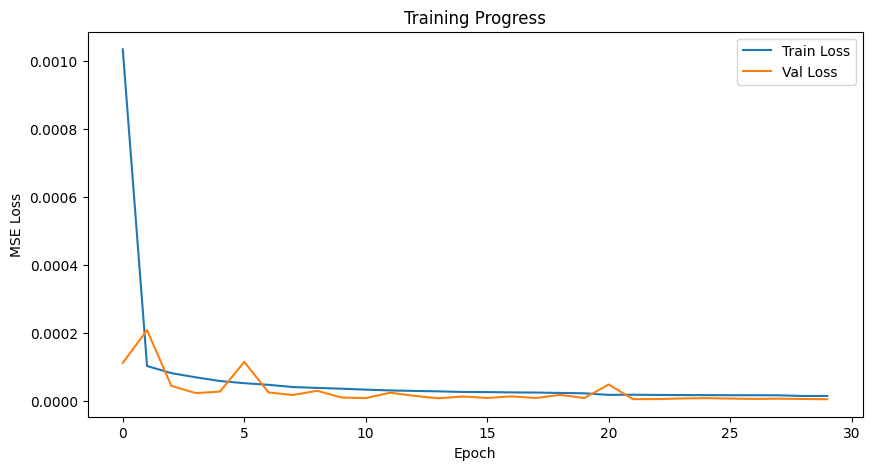

In [10]:
# Plot Loss
plt.figure(figsize=(10, 5))
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Training Progress')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.show()